<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID de ligne             9994 non-null   int64         
 1   Identifiant commande    9994 non-null   str           
 2   Date de commande        9994 non-null   datetime64[us]
 3   Date d'expédition       9994 non-null   datetime64[us]
 4   Mode d'expédition       9994 non-null   str           
 5   Identifiant client      9994 non-null   str           
 6   Nom du client           9994 non-null   str           
 7   Segment                 9994 non-null   str           
 8   Pays                    9994 non-null   str           
 9   Ville                   9994 non-null   str           
 10  État                    9994 non-null   str           
 11  Code postal             9994 non-null   int64         
 12  Région                  9994 non-null   str           
 13 

C:\Users\pc\AppData\Local\Temp\ipykernel_15608\2993392561.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_state.head(10).index, y=sales_by_state.head(10).values, palette='Blues_r')


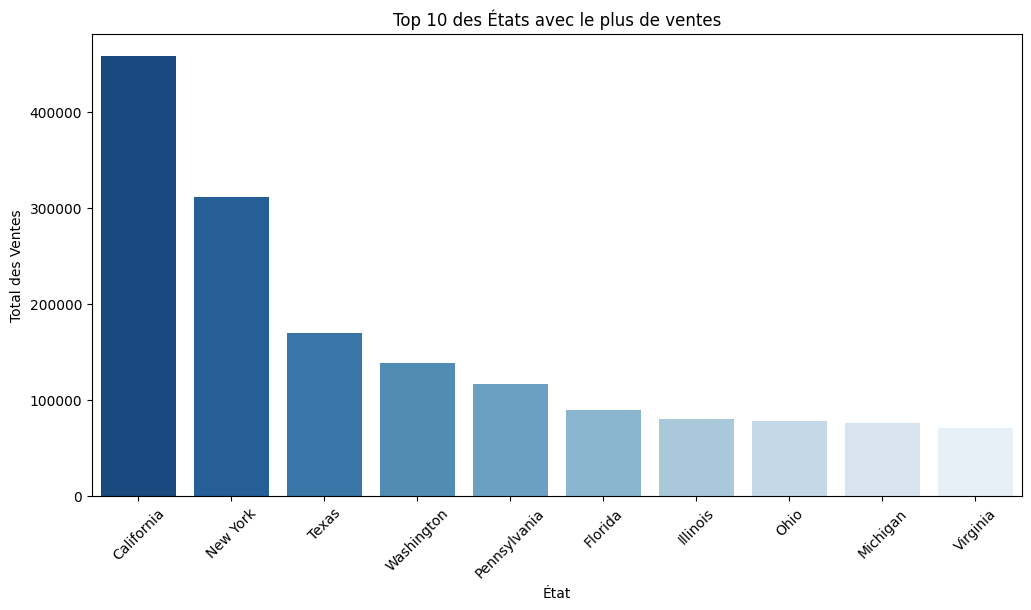

                 Ventes    Bénéfice
État                               
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


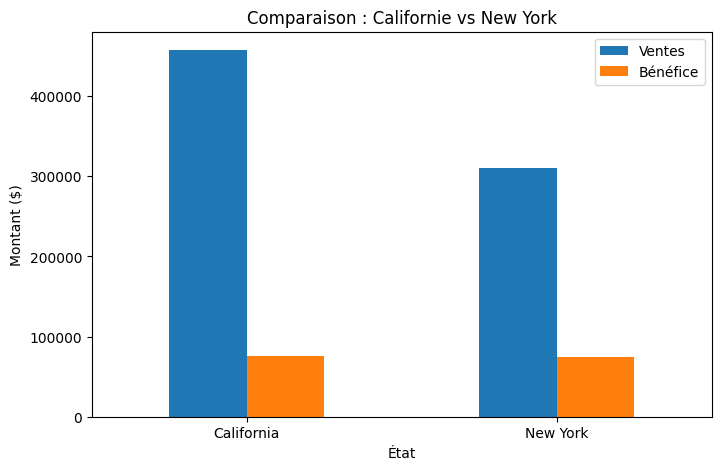

États les plus rentables (Marge %):
                         Ventes    Bénéfice    Marge_%
État                                                  
District of Columbia   2865.020   1059.5893  36.983662
Delaware              27451.069   9977.3748  36.346034
Minnesota             29863.150  10823.1874  36.242618
Maine                  1270.530    454.4862  35.771387
Arkansas              11678.130   4008.6871  34.326447

États les moins rentables ou en perte (Marge %):
                Ventes    Bénéfice    Marge_%
État                                         
Texas      170188.0458 -25729.3563 -15.118192
Illinois    80166.1010 -12607.8870 -15.727205
Tennessee   30661.8730  -5341.6936 -17.421289
Colorado    32108.1180  -6527.8579 -20.330864
Ohio        78258.1360 -16971.3766 -21.686405
                    Ventes    Bénéfice    Marge_%
Ville                                            
Lafayette       25036.2000  10018.3876  40.015608
Detroit         42446.9440  13181.7908  31.054746
Jackson

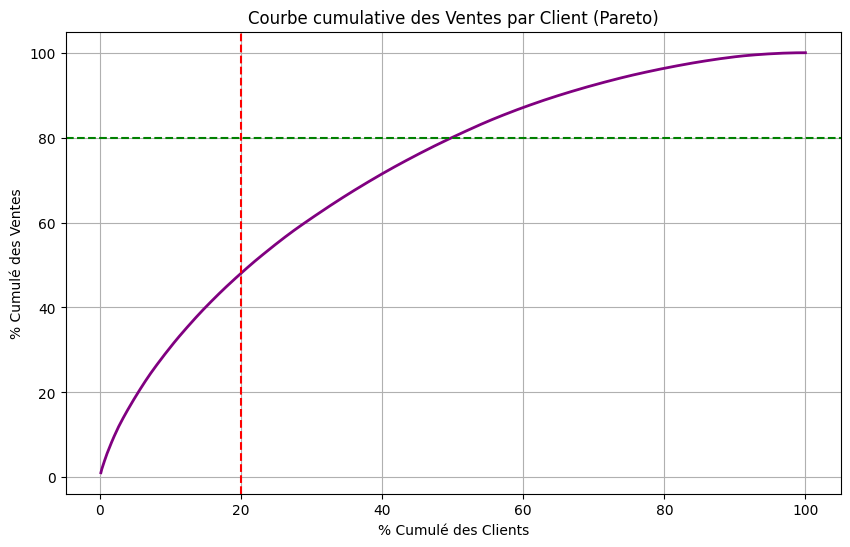

In [3]:
#Chargement et Prétraitement des données

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('US Superstore data.xls')

traduction_colonnes = {
    'Row ID': 'ID de ligne',
    'Order ID': 'Identifiant commande',
    'Order Date': 'Date de commande',
    'Ship Date': 'Date d\'expédition',
    'Ship Mode': 'Mode d\'expédition',
    'Customer ID': 'Identifiant client',
    'Customer Name': 'Nom du client',
    'Segment': 'Segment',
    'Country': 'Pays',
    'City': 'Ville',
    'State': 'État',
    'Postal Code': 'Code postal',
    'Region': 'Région',
    'Product ID': 'Identifiant du produit',
    'Category': 'Catégorie',
    'Sub-Category': 'Sous-catégorie',
    'Product Name': 'Nom du produit',
    'Sales': 'Ventes',
    'Quantity': 'Quantité',
    'Discount': 'Réduction',
    'Profit': 'Bénéfice'
}

df = df.rename(columns=traduction_colonnes)

df['Date de commande'] = pd.to_datetime(df['Date de commande'])
df['Date d\'expédition'] = pd.to_datetime(df['Date d\'expédition'])

print(df.info())

#1. États enregistrant le plus de ventes
sales_by_state = df.groupby('État')['Ventes'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_state.head(10).index, y=sales_by_state.head(10).values, palette='Blues_r')
plt.title('Top 10 des États avec le plus de ventes')
plt.xlabel('État')
plt.ylabel('Total des Ventes')
plt.xticks(rotation=45)
plt.show()

#2. Comparaison entre New York et la Californie
ny_ca_data = df[df['État'].isin(['New York', 'California'])]

comp_ny_ca = ny_ca_data.groupby('État')[['Ventes', 'Bénéfice']].sum()
print(comp_ny_ca)

comp_ny_ca.plot(kind='bar', figsize=(8, 5))
plt.title('Comparaison : Californie vs New York')
plt.ylabel('Montant ($)')
plt.xticks(rotation=0)
plt.show()

#3. Différences de rentabilité entre les États
state_profitability = df.groupby('État').agg({'Ventes':'sum', 'Bénéfice':'sum'})
state_profitability['Marge_%'] = (state_profitability['Bénéfice'] / state_profitability['Ventes']) * 100
state_profitability = state_profitability.sort_values(by='Marge_%', ascending=False)

print("États les plus rentables (Marge %):")
print(state_profitability.head())
print("\nÉtats les moins rentables ou en perte (Marge %):")
print(state_profitability.tail())

#4. Analyse des 20 premières villes
top_20_cities_sales = df.groupby('Ville')['Ventes'].sum().sort_values(ascending=False).head(20)
top_20_cities_profit = df.groupby('Ville')['Bénéfice'].sum().sort_values(ascending=False).head(20)

top_20_sales_df = df[df['Ville'].isin(top_20_cities_sales.index)].groupby('Ville').agg({'Ventes':'sum', 'Bénéfice':'sum'})
top_20_sales_df['Marge_%'] = (top_20_sales_df['Bénéfice'] / top_20_sales_df['Ventes']) * 100
print(top_20_sales_df.sort_values(by='Marge_%', ascending=False))


#Analyse des Clients
#1. Client exceptionnel à New York
ny_customers = df[df['État'] == 'New York']

ny_top_customer = ny_customers.groupby(['Identifiant client', 'Nom du client'])[['Ventes', 'Bénéfice']].sum()
print(ny_top_customer.sort_values(by='Ventes', ascending=False).head(1))

#2. Les 20 meilleurs clients en termes de ventes
top_20_customers = df.groupby(['Identifiant client', 'Nom du client'])['Ventes'].sum().sort_values(ascending=False).head(20)
print(top_20_customers)


#Application du Principe de Pareto
#1. Contribution des 20 % de clients aux bénéfices
customer_profit = df.groupby('Identifiant client')['Bénéfice'].sum().sort_values(ascending=False).to_frame()
customer_profit = customer_profit[customer_profit['Bénéfice'] > 0]

customer_profit['Bénéfice_Cumulé'] = customer_profit['Bénéfice'].cumsum()
customer_profit['%_Bénéfice_Cumulé'] = (customer_profit['Bénéfice_Cumulé'] / customer_profit['Bénéfice'].sum()) * 100

customer_profit['Rang_Client'] = range(1, len(customer_profit) + 1)
customer_profit['%_Clients_Cumulé'] = (customer_profit['Rang_Client'] / len(customer_profit)) * 100

pareto_client_profit = customer_profit[customer_profit['%_Clients_Cumulé'] <= 20].iloc[-1]
print(f"Les premiers 20% de clients génèrent : {pareto_client_profit['%_Bénéfice_Cumulé']:.2f}% des bénéfices positifs.")

#2. Courbe cumulative des ventes par client (Graphique de Pareto)
customer_sales = df.groupby('Identifiant client')['Ventes'].sum().sort_values(ascending=False).to_frame()
customer_sales['Ventes_Cumulées'] = customer_sales['Ventes'].cumsum()
customer_sales['%_Ventes_Cumulées'] = (customer_sales['Ventes_Cumulées'] / customer_sales['Ventes'].sum()) * 100

total_clients = len(customer_sales)
customer_sales['%_Clients_Cumulé'] = (range(1, total_clients + 1))
customer_sales['%_Clients_Cumulé'] = (customer_sales['%_Clients_Cumulé'] / total_clients) * 100

plt.figure(figsize=(10, 6))
plt.plot(customer_sales['%_Clients_Cumulé'].values, customer_sales['%_Ventes_Cumulées'].values, color='purple', lw=2)
plt.axvline(x=20, color='red', linestyle='--')
plt.axhline(y=80, color='green', linestyle='--')
plt.title('Courbe cumulative des Ventes par Client (Pareto)')
plt.xlabel('% Cumulé des Clients')
plt.ylabel('% Cumulé des Ventes')
plt.grid(True)
plt.show()